In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "qnli"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['question', 'sentence', 'label', 'idx'],
    num_rows: 104743
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'question': 'When did the third Digimon series begin?',
 'sentence': 'Unlike the two seasons before it and most of the seasons that followed, Digimon Tamers takes a darker and more realistic approach to its story featuring Digimon who do not reincarnate after their deaths and more complex character development in the original Japanese.',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['question'], raw_train_dataset[5]['sentence']

("When is the term 'German dialects' used in regard to the German language?",
 'When talking about the German language, the term German dialects is only used for the traditional regional varieties.')

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'question': Value('string'),
 'sentence': Value('string'),
 'label': ClassLabel(names=['entailment', 'not_entailment']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["question"], example["sentence"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["question", "sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 84]),
 'token_type_ids': torch.Size([32, 84]),
 'attention_mask': torch.Size([32, 84])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7970, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [26]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [27]:
from train_eval_func import eval_loop

In [28]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9134175361522973}

### Load Trained Weights for Model with 7 Layers

In [29]:
import os
from merge_helper import merge_bert_layers, LayerMergeTracker, apply_layer_tracking_to_model
from train_eval_func import train, get_primary_metric, set_lr_scheduler, get_recovery_epoch
from torch.optim import AdamW

In [30]:
model_7 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-7-{task_name}.pt', map_location=device)

In [32]:
model_7 = apply_layer_tracking_to_model(model_7, graft_state['layer_track'])

In [33]:
len(model_7.bert.encoder.layer)

7

In [34]:
model_7.to(device)
device

device(type='cuda', index=1)

In [35]:
model_7.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [36]:
eval_loop(model_7, val_dataloader, task_name, device)[0]

{'accuracy': 0.9018854109463664}

### Load Trained Weights for Model with 8 Layers

In [37]:
model_8 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-8-{task_name}.pt', map_location=device)

In [39]:
model_8 = apply_layer_tracking_to_model(model_8, graft_state['layer_track'])

In [40]:
len(model_8.bert.encoder.layer)

8

In [41]:
model_8.to(device)
device

device(type='cuda', index=1)

In [42]:
model_8.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [43]:
eval_loop(model_8, val_dataloader, task_name, device)[0]

{'accuracy': 0.8991396668497162}

### Load Trained Weights for Model with 6 Layers

In [44]:
model_6 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [45]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-6-{task_name}.pt', map_location=device)

In [46]:
model_6 = apply_layer_tracking_to_model(model_6, graft_state['layer_track'])

In [47]:
len(model_6.bert.encoder.layer)

6

In [48]:
model_6.to(device)
device

device(type='cuda', index=1)

In [49]:
model_6.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [50]:
eval_loop(model_6, val_dataloader, task_name, device)[0]

{'accuracy': 0.8832143510891451}

# 5. Pruning Study

In [51]:
analysis_save_path = f'./save_analysis/{task_name}'

### Masking 10 percent of amount

In [52]:
num_att_mask = int(12 * 12 * 0.1)
num_att_mask

14

In [53]:
num_int_mask = int(model.bert.encoder.layer[0].intermediate.dense.weight.shape[0] * 12 * 0.1)
num_int_mask

3686

## 5.1 Attention Heads

### 12 Layers

In [54]:
from structure_prune_helper import register_importance_masks, remove_importance_masks, iterativeMask, plot_results, plot_masking_comparison

In [55]:
register_importance_masks(model, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (12 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (12 heads)
  Layer 6: Registered masks (12 heads)
  Layer 7: Registered masks (12 heads)
  Layer 8: Registered masks (12 heads)
  Layer 9: Registered masks (12 heads)
  Layer 10: Registered masks (12 heads)
  Layer 11: Registered masks (12 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [56]:
mask_history_head = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9134

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:40<00:00,  2.49it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 11 (91.67%)
Layer: 1, total: 12, Remain: 10 (83.33%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 12, Remain: 11 (91.67%)
Layer: 6, total: 12, Remain: 11 (91.67%)
Layer: 7, total: 12, Remain: 9 (75.0%)
Layer: 8, total: 12, Remain: 12 (100.0%)
Layer: 9, total: 12, Remain: 11 (91.67%)
Layer: 10, total: 12, Remain: 8 (66.67%)
Layer: 11, total: 12, Remain: 11 (91.67%)
  Metrics:
    ★ accuracy: 0.9129

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [01:04<00:00,  1.55it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 10 (83.33%)
Layer: 1, total: 12, Remain: 8 (66.67%)
Layer: 2, total: 12, Remain: 10 (83.33%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 10 (83.33%)
Layer: 5, total: 12, Remain: 10 (83.33%)
Layer: 6, total: 12, Remain: 11 (91.67%)
Layer: 7, total: 12, Remain: 7 (58.33%)
Layer: 8, total: 12, Remain: 10 (83.33%)
Layer: 9, total: 12, Remain: 11 (91.67%)
Layer: 10, total: 12, Remain: 8 (66.67%)
Layer: 11, total: 12, Remain: 9 (75.0%)
  Metrics:
    ★ accuracy: 0.9092

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 2 (16.67%)
Layer: 1, total: 12, Remain: 3 (25.0%)
Layer: 2, total: 12, Remain: 3 (25.0%)
Layer: 3, total: 12, Remain: 4 (33.33%)
Layer: 4, total: 12, Remain: 5 (41.67%)
Layer: 5, total: 12, Remain: 3 (25.0%)
Layer: 6, total: 12, Remain: 2 (16.67%)
Layer: 7, total: 12, Remain: 3 (25.0%)
Layer: 8, total: 12, Remain: 7 (58.33%)
Layer: 9, total: 12, Remain: 4 (33.33%)
Layer: 10, total: 12, Remain: 5 (41.67%)
Layer: 11, total: 12, Remain: 5 (41.67%)
  Metrics:
    ★ accuracy: 0.8422

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:21<00:00,  4.72it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 1 (8.33%)
Layer: 1, total: 12, Remain: 3 (25.0%)
Layer: 2, total: 12, Remain: 2 (16.67%)
Layer: 3, total: 12, Remain: 2 (16.67%)
Layer: 4, total: 12, Remain: 4 (33.33%)
Layer: 5, total: 12, Remain: 0 (0.0%)
Layer: 6, total: 12, Remain: 2 (16.67%)
Layer: 7, total: 12, Remain: 3 (25.0%)
Layer: 8, total: 12, Remain: 5 (41.67%)
Layer: 9, total: 12, Remain: 3 (25.0%)
Layer: 10, total: 12, Remain: 4 (33.33%)
Layer: 11, total: 12, Remain: 3 (25.0%)
  Metrics:
    ★ accuracy: 0.6961

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:21<00:00,  4.66it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 0 (0.0%)
Layer: 1, total: 12, Remain: 1 (8.33%)
Layer: 2, total: 12, Remain: 1 (8.33%)
Layer: 3, total: 12, Remain: 2 (16.67%)
Layer: 4, total: 12, Remain: 4 (33.33%)
Layer: 5, total: 12, Remain: 0 (0.0%)
Layer: 6, total: 12, Remain: 1 (8.33%)
Layer: 7, total: 12, Remain: 1 (8.33%)
Layer: 8, total: 12, Remain: 3 (25.0%)
Layer: 9, total: 12, Remain: 2 (16.67%)
Layer: 10, total: 12, Remain: 2 (16.67%)
Layer: 11, total: 12, Remain: 1 (8.33%)
  Metrics:
    ★ accuracy: 0.5255


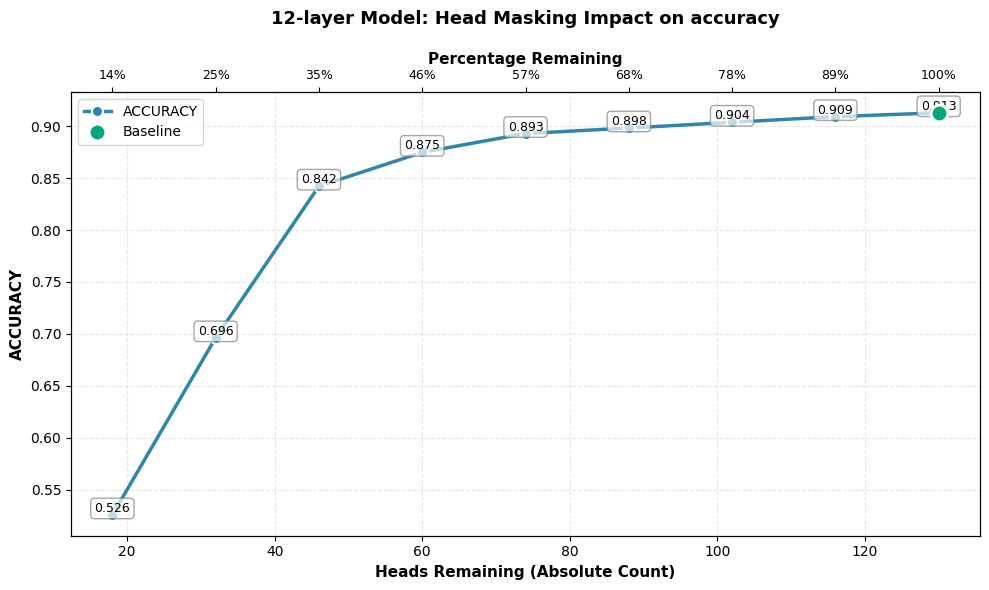

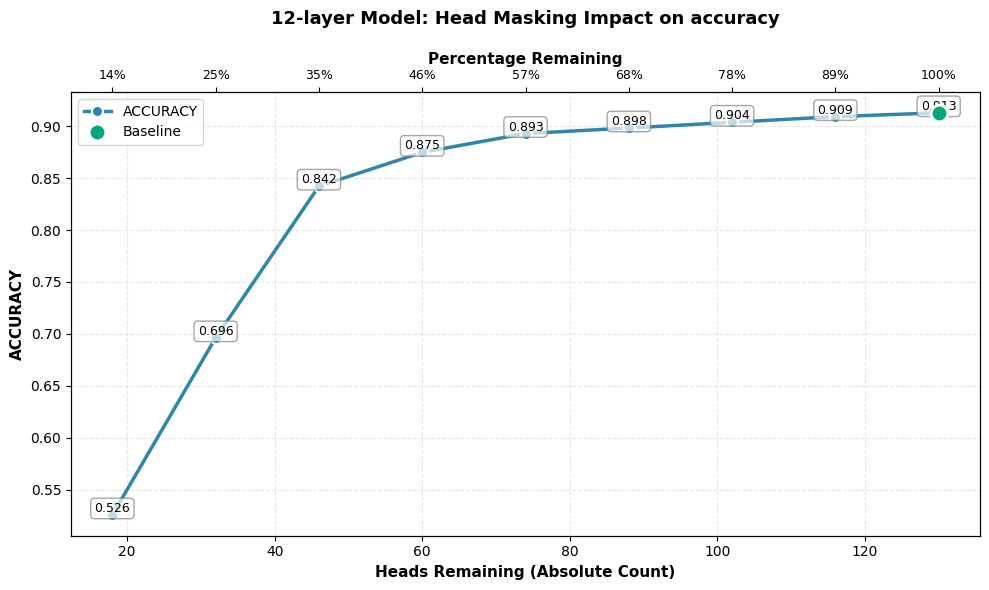

In [57]:
plot_results(
        mask_history_head,
        metric='accuracy',
        component='heads',
        title='12-layer Model: Head Masking Impact on accuracy'
)

In [58]:
remove_importance_masks(model, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [59]:
torch.save(mask_history_head, analysis_save_path + '/head.pt')

### 8 Layers

In [60]:
register_importance_masks(model_8, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (12 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (36 heads)
  Layer 6: Registered masks (36 heads)
  Layer 7: Registered masks (12 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-4): 5 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [61]:
mask_history_head_8 = iterativeMask(
    model_8, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.8991

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:23<00:00,  4.33it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 36, Remain: 29 (80.56%)
Layer: 6, total: 36, Remain: 29 (80.56%)
Layer: 7, total: 12, Remain: 12 (100.0%)
  Metrics:
    ★ accuracy: 0.8995

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:20<00:00,  4.89it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 11 (91.67%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 36, Remain: 23 (63.89%)
Layer: 6, total: 36, Remain: 22 (61.11%)
Layer: 7, total: 12, Remain: 12 (100.0%)
  Metrics:
    ★ accuracy: 0.8990

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 2 (16.67%)
Layer: 1, total: 12, Remain: 5 (41.67%)
Layer: 2, total: 12, Remain: 4 (33.33%)
Layer: 3, total: 12, Remain: 3 (25.0%)
Layer: 4, total: 12, Remain: 6 (50.0%)
Layer: 5, total: 36, Remain: 7 (19.44%)
Layer: 6, total: 36, Remain: 13 (36.11%)
Layer: 7, total: 12, Remain: 6 (50.0%)
  Metrics:
    ★ accuracy: 0.8380

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:18<00:00,  5.35it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 1 (8.33%)
Layer: 1, total: 12, Remain: 2 (16.67%)
Layer: 2, total: 12, Remain: 2 (16.67%)
Layer: 3, total: 12, Remain: 2 (16.67%)
Layer: 4, total: 12, Remain: 6 (50.0%)
Layer: 5, total: 36, Remain: 5 (13.89%)
Layer: 6, total: 36, Remain: 8 (22.22%)
Layer: 7, total: 12, Remain: 6 (50.0%)
  Metrics:
    ★ accuracy: 0.7701

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:20<00:00,  4.88it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 0 (0.0%)
Layer: 1, total: 12, Remain: 0 (0.0%)
Layer: 2, total: 12, Remain: 1 (8.33%)
Layer: 3, total: 12, Remain: 1 (8.33%)
Layer: 4, total: 12, Remain: 3 (25.0%)
Layer: 5, total: 36, Remain: 2 (5.56%)
Layer: 6, total: 36, Remain: 7 (19.44%)
Layer: 7, total: 12, Remain: 4 (33.33%)
  Metrics:
    ★ accuracy: 0.6996


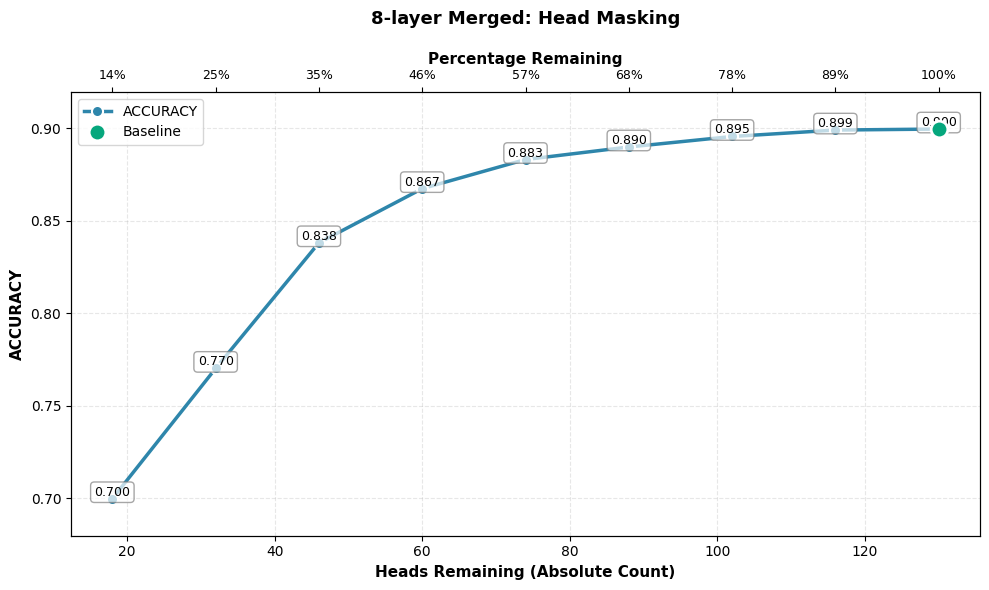

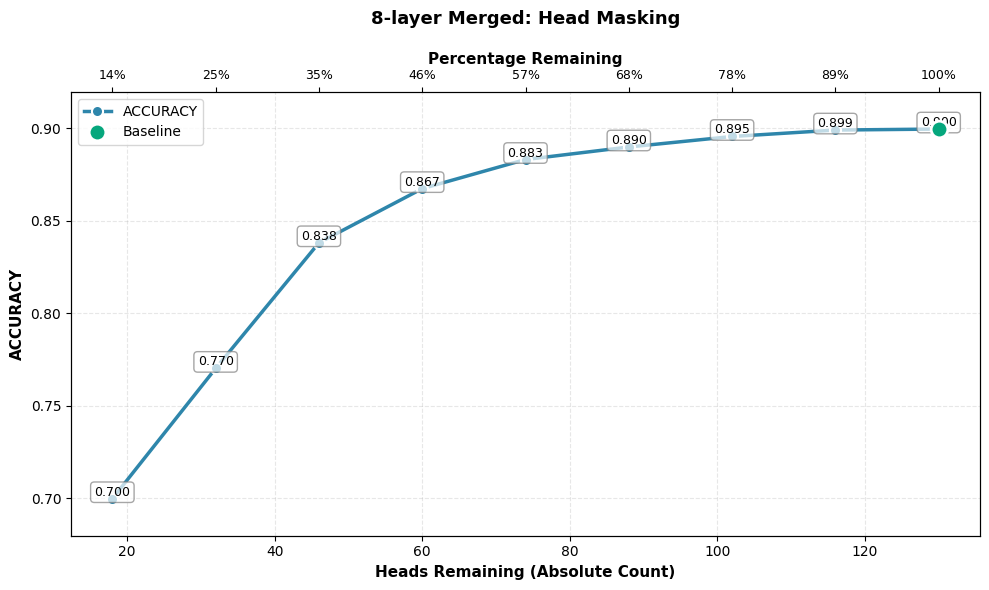

In [62]:
plot_results(
        mask_history_head_8,
        metric='accuracy',
        component='heads',
        title='8-layer Merged: Head Masking'
)

In [63]:
remove_importance_masks(model_8, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [64]:
torch.save(mask_history_head_8, analysis_save_path + '/head_8.pt')

### 7 Layers

In [65]:
register_importance_masks(model_7, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (24 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (36 heads)
  Layer 5: Registered masks (36 heads)
  Layer 6: Registered masks (12 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [66]:
mask_history_head_7 = iterativeMask(
    model_7, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9019

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:19<00:00,  5.00it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 36, Remain: 31 (86.11%)
Layer: 5, total: 36, Remain: 27 (75.0%)
Layer: 6, total: 12, Remain: 12 (100.0%)
  Metrics:
    ★ accuracy: 0.9035

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:20<00:00,  4.95it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 21 (87.5%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 36, Remain: 25 (69.44%)
Layer: 5, total: 36, Remain: 23 (63.89%)
Layer: 6, total: 12, Remain: 11 (91.67%)
  Metrics:
    ★ accuracy: 0.9028

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 5 (41.67%)
Layer: 1, total: 24, Remain: 5 (20.83%)
Layer: 2, total: 12, Remain: 5 (41.67%)
Layer: 3, total: 12, Remain: 7 (58.33%)
Layer: 4, total: 36, Remain: 7 (19.44%)
Layer: 5, total: 36, Remain: 12 (33.33%)
Layer: 6, total: 12, Remain: 5 (41.67%)
  Metrics:
    ★ accuracy: 0.8105

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:19<00:00,  5.20it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 4 (33.33%)
Layer: 1, total: 24, Remain: 3 (12.5%)
Layer: 2, total: 12, Remain: 3 (25.0%)
Layer: 3, total: 12, Remain: 6 (50.0%)
Layer: 4, total: 36, Remain: 4 (11.11%)
Layer: 5, total: 36, Remain: 7 (19.44%)
Layer: 6, total: 12, Remain: 5 (41.67%)
  Metrics:
    ★ accuracy: 0.7794

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [01:44<00:00,  1.05s/it]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 1 (8.33%)
Layer: 1, total: 24, Remain: 2 (8.33%)
Layer: 2, total: 12, Remain: 1 (8.33%)
Layer: 3, total: 12, Remain: 3 (25.0%)
Layer: 4, total: 36, Remain: 1 (2.78%)
Layer: 5, total: 36, Remain: 5 (13.89%)
Layer: 6, total: 12, Remain: 5 (41.67%)
  Metrics:
    ★ accuracy: 0.6416


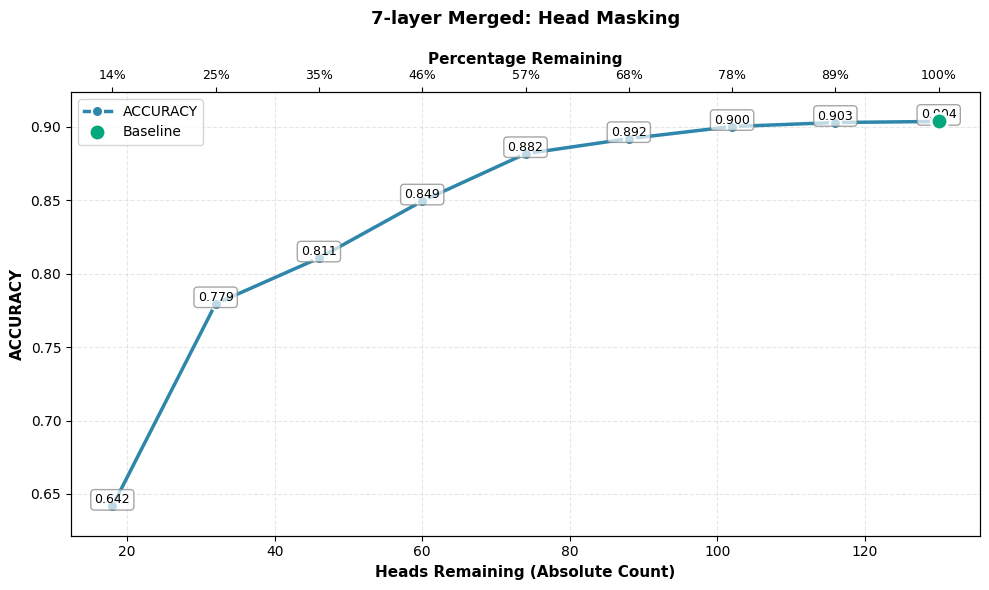

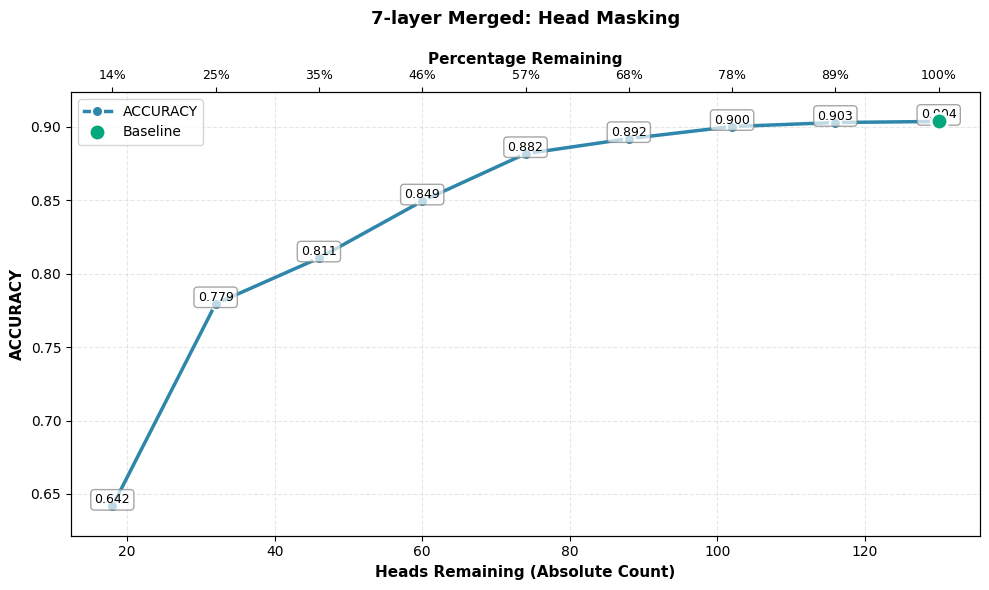

In [67]:
plot_results(
        mask_history_head_7,
        metric='accuracy',
        component='heads',
        title='7-layer Merged: Head Masking'
)

In [68]:
remove_importance_masks(model_7, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [69]:
torch.save(mask_history_head_7, analysis_save_path + '/head_7.pt')

### 6 Layers

In [70]:
register_importance_masks(model_6, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (24 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (72 heads)
  Layer 5: Registered masks (12 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [71]:
mask_history_head_6 = iterativeMask(
    model_6, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.8832

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:19<00:00,  5.03it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 72, Remain: 58 (80.56%)
Layer: 5, total: 12, Remain: 12 (100.0%)
  Metrics:
    ★ accuracy: 0.8845

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:18<00:00,  5.43it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 23 (95.83%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 72, Remain: 45 (62.5%)
Layer: 5, total: 12, Remain: 12 (100.0%)
  Metrics:
    ★ accuracy: 0.8825

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 7 (58.33%)
Layer: 1, total: 24, Remain: 6 (25.0%)
Layer: 2, total: 12, Remain: 6 (50.0%)
Layer: 3, total: 12, Remain: 7 (58.33%)
Layer: 4, total: 72, Remain: 13 (18.06%)
Layer: 5, total: 12, Remain: 7 (58.33%)
  Metrics:
    ★ accuracy: 0.8254

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:17<00:00,  5.57it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 4 (33.33%)
Layer: 1, total: 24, Remain: 4 (16.67%)
Layer: 2, total: 12, Remain: 4 (33.33%)
Layer: 3, total: 12, Remain: 6 (50.0%)
Layer: 4, total: 72, Remain: 7 (9.72%)
Layer: 5, total: 12, Remain: 7 (58.33%)
  Metrics:
    ★ accuracy: 0.7979

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:20<00:00,  4.82it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 2 (16.67%)
Layer: 1, total: 24, Remain: 3 (12.5%)
Layer: 2, total: 12, Remain: 1 (8.33%)
Layer: 3, total: 12, Remain: 2 (16.67%)
Layer: 4, total: 72, Remain: 7 (9.72%)
Layer: 5, total: 12, Remain: 3 (25.0%)
  Metrics:
    ★ accuracy: 0.7441


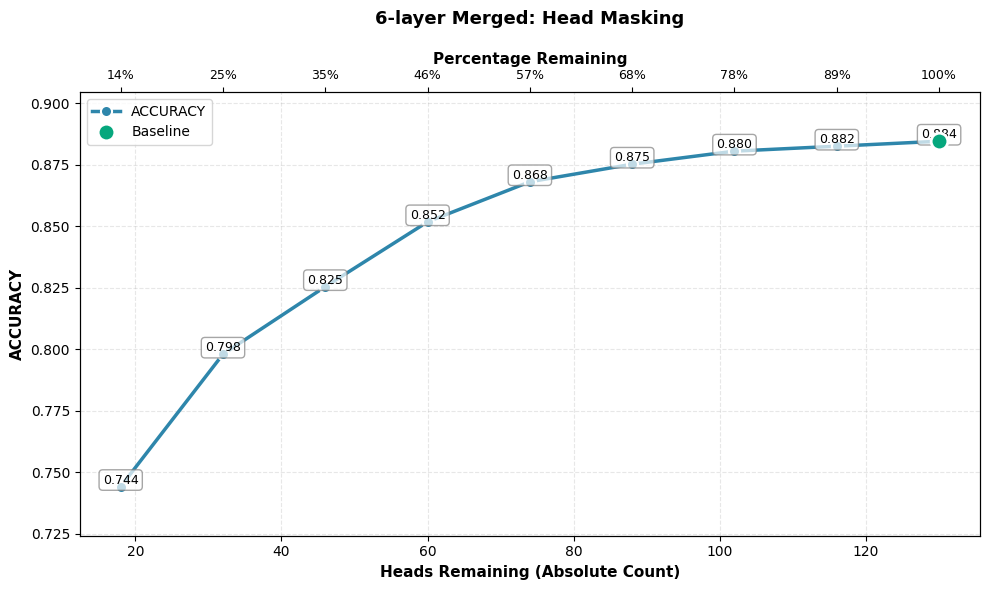

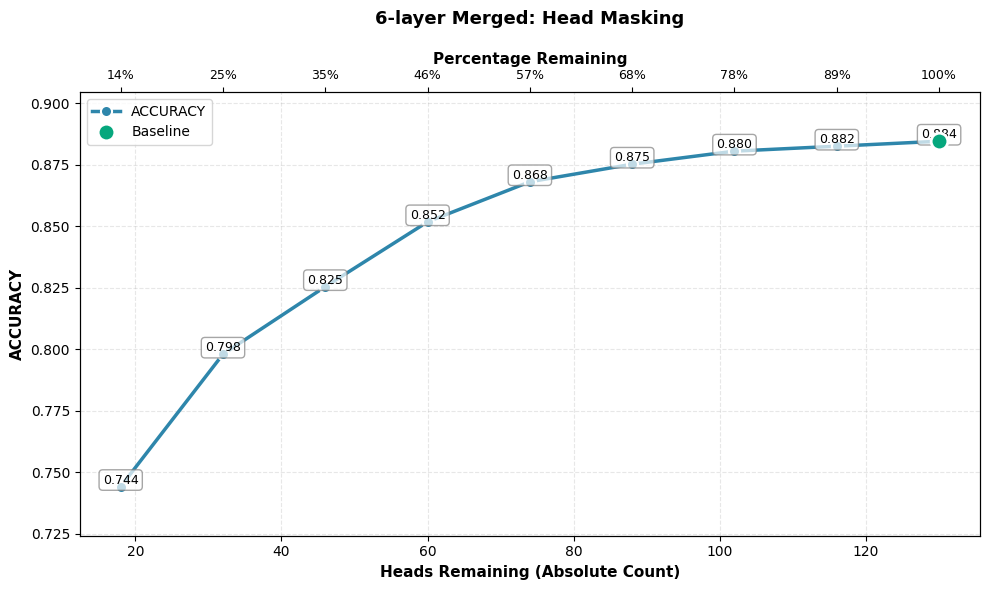

In [72]:
plot_results(
        mask_history_head_6,
        metric='accuracy',
        component='heads',
        title='6-layer Merged: Head Masking'
)

In [73]:
remove_importance_masks(model_6, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [74]:
torch.save(mask_history_head_6, analysis_save_path + '/head_6.pt')

### Comparision Plot

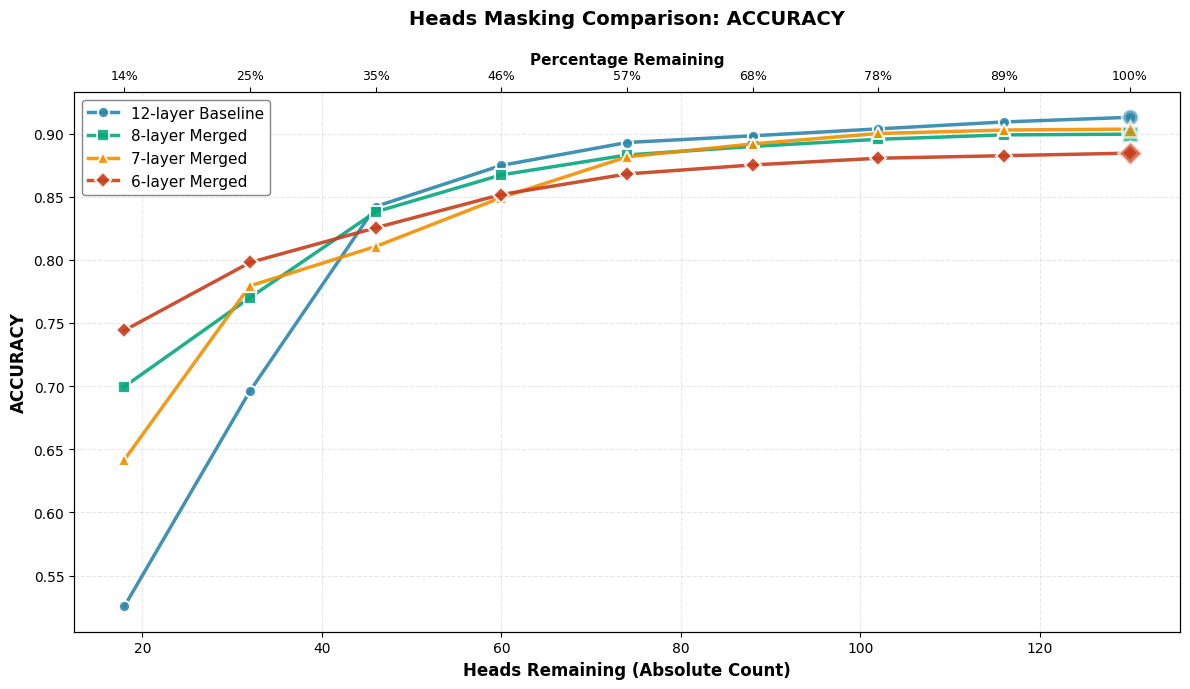

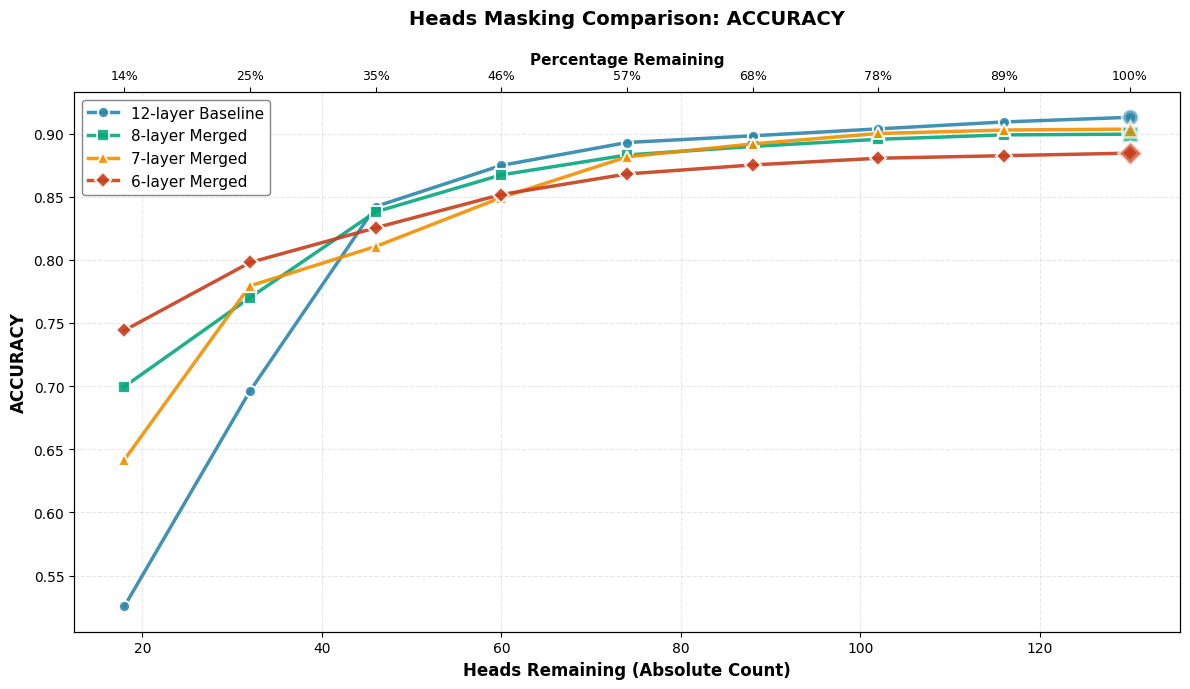

In [75]:
plot_masking_comparison(
    [mask_history_head, mask_history_head_8, mask_history_head_7, mask_history_head_6], 
    labels=['12-layer Baseline', '8-layer Merged', '7-layer Merged', '6-layer Merged'],
    metric='accuracy', component='heads'
)

## 5.2 FFN Neurons

### 12 Layers

In [76]:
register_importance_masks(model, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (3072 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (3072 neurons)
  Layer 6: Registered masks (3072 neurons)
  Layer 7: Registered masks (3072 neurons)
  Layer 8: Registered masks (3072 neurons)
  Layer 9: Registered masks (3072 neurons)
  Layer 10: Registered masks (3072 neurons)
  Layer 11: Registered masks (3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [77]:
mask_history_neuron = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9134

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:23<00:00,  4.34it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3049 (99.25%)
Layer: 1, total: 3072, Remain: 3057 (99.51%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 3072, Remain: 3070 (99.93%)
Layer: 4, total: 3072, Remain: 3068 (99.87%)
Layer: 5, total: 3072, Remain: 3066 (99.8%)
Layer: 6, total: 3072, Remain: 3069 (99.9%)
Layer: 7, total: 3072, Remain: 3066 (99.8%)
Layer: 8, total: 3072, Remain: 3070 (99.93%)
Layer: 9, total: 3072, Remain: 3053 (99.38%)
Layer: 10, total: 3072, Remain: 2401 (78.16%)
Layer: 11, total: 3072, Remain: 138 (4.49%)
  Metrics:
    ★ accuracy: 0.9145

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:21<00:00,  4.67it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 2749 (89.49%)
Layer: 1, total: 3072, Remain: 2857 (93.0%)
Layer: 2, total: 3072, Remain: 2979 (96.97%)
Layer: 3, total: 3072, Remain: 3022 (98.37%)
Layer: 4, total: 3072, Remain: 3022 (98.37%)
Layer: 5, total: 3072, Remain: 3017 (98.21%)
Layer: 6, total: 3072, Remain: 3040 (98.96%)
Layer: 7, total: 3072, Remain: 3017 (98.21%)
Layer: 8, total: 3072, Remain: 2888 (94.01%)
Layer: 9, total: 3072, Remain: 2298 (74.8%)
Layer: 10, total: 3072, Remain: 568 (18.49%)
Layer: 11, total: 3072, Remain: 35 (1.14%)
  Metrics:
    ★ accuracy: 0.9151

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 923 (30.05%)
Layer: 1, total: 3072, Remain: 875 (28.48%)
Layer: 2, total: 3072, Remain: 856 (27.86%)
Layer: 3, total: 3072, Remain: 1126 (36.65%)
Layer: 4, total: 3072, Remain: 1343 (43.72%)
Layer: 5, total: 3072, Remain: 1514 (49.28%)
Layer: 6, total: 3072, Remain: 1716 (55.86%)
Layer: 7, total: 3072, Remain: 1420 (46.22%)
Layer: 8, total: 3072, Remain: 993 (32.32%)
Layer: 9, total: 3072, Remain: 234 (7.62%)
Layer: 10, total: 3072, Remain: 54 (1.76%)
Layer: 11, total: 3072, Remain: 8 (0.26%)
  Metrics:
    ★ accuracy: 0.8429

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.79it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 738 (24.02%)
Layer: 1, total: 3072, Remain: 642 (20.9%)
Layer: 2, total: 3072, Remain: 585 (19.04%)
Layer: 3, total: 3072, Remain: 709 (23.08%)
Layer: 4, total: 3072, Remain: 836 (27.21%)
Layer: 5, total: 3072, Remain: 921 (29.98%)
Layer: 6, total: 3072, Remain: 1113 (36.23%)
Layer: 7, total: 3072, Remain: 916 (29.82%)
Layer: 8, total: 3072, Remain: 702 (22.85%)
Layer: 9, total: 3072, Remain: 162 (5.27%)
Layer: 10, total: 3072, Remain: 45 (1.46%)
Layer: 11, total: 3072, Remain: 7 (0.23%)
  Metrics:
    ★ accuracy: 0.7974

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:24<00:00,  4.14it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 474 (15.43%)
Layer: 1, total: 3072, Remain: 377 (12.27%)
Layer: 2, total: 3072, Remain: 282 (9.18%)
Layer: 3, total: 3072, Remain: 318 (10.35%)
Layer: 4, total: 3072, Remain: 420 (13.67%)
Layer: 5, total: 3072, Remain: 398 (12.96%)
Layer: 6, total: 3072, Remain: 514 (16.73%)
Layer: 7, total: 3072, Remain: 418 (13.61%)
Layer: 8, total: 3072, Remain: 346 (11.26%)
Layer: 9, total: 3072, Remain: 94 (3.06%)
Layer: 10, total: 3072, Remain: 42 (1.37%)
Layer: 11, total: 3072, Remain: 7 (0.23%)
  Metrics:
    ★ accuracy: 0.7210


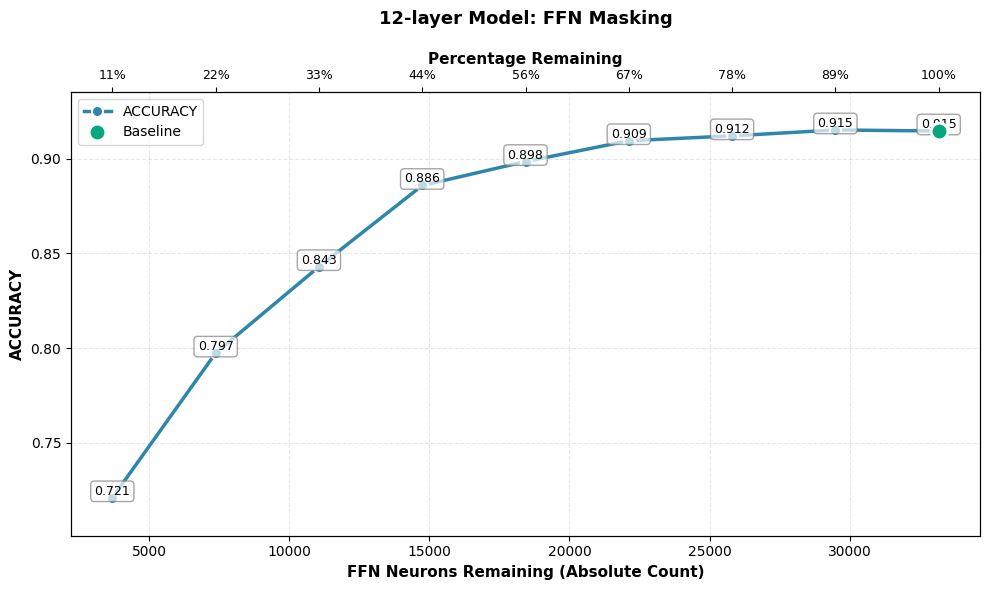

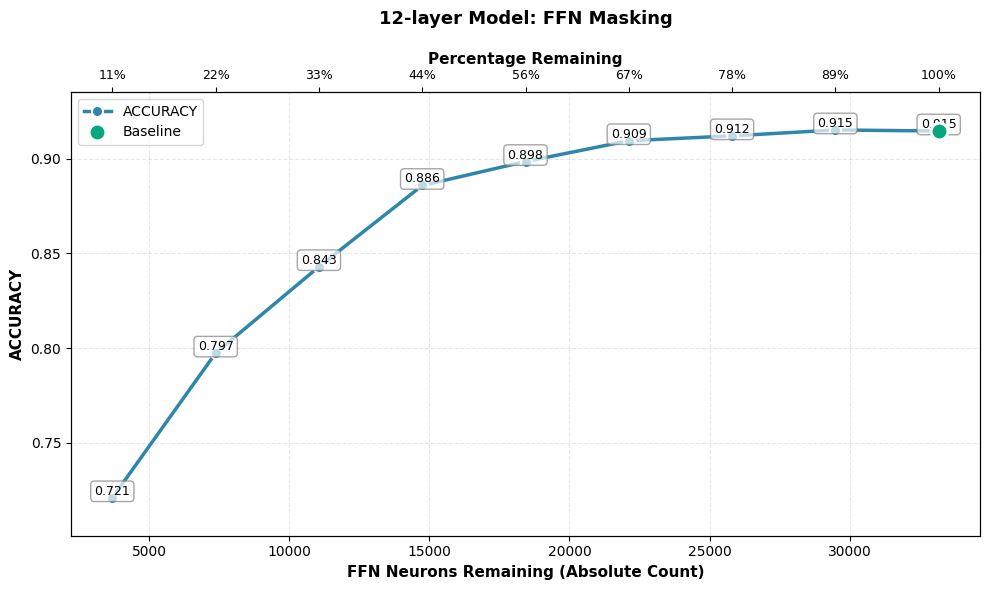

In [78]:
plot_results(mask_history_neuron, metric='accuracy', component='ffn', title='12-layer Model: FFN Masking')

In [79]:
remove_importance_masks(model, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [80]:
torch.save(mask_history_neuron, analysis_save_path + '/neuron.pt')

### 8 Layers

In [81]:
register_importance_masks(model_8, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (3072 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (9216 neurons)
  Layer 6: Registered masks (9216 neurons)
  Layer 7: Registered masks (3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-4): 5 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [82]:
mask_history_neuron_8 = iterativeMask(
    model_8, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.8991

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.84it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3065 (99.77%)
Layer: 1, total: 3072, Remain: 3067 (99.84%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 3072, Remain: 3071 (99.97%)
Layer: 4, total: 3072, Remain: 3071 (99.97%)
Layer: 5, total: 9216, Remain: 9199 (99.82%)
Layer: 6, total: 9216, Remain: 8234 (89.34%)
Layer: 7, total: 3072, Remain: 400 (13.02%)
  Metrics:
    ★ accuracy: 0.8988

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.91it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 2998 (97.59%)
Layer: 1, total: 3072, Remain: 3021 (98.34%)
Layer: 2, total: 3072, Remain: 3058 (99.54%)
Layer: 3, total: 3072, Remain: 3065 (99.77%)
Layer: 4, total: 3072, Remain: 3065 (99.77%)
Layer: 5, total: 9216, Remain: 9050 (98.2%)
Layer: 6, total: 9216, Remain: 5048 (54.77%)
Layer: 7, total: 3072, Remain: 187 (6.09%)
  Metrics:
    ★ accuracy: 0.8984

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1117 (36.36%)
Layer: 1, total: 3072, Remain: 1171 (38.12%)
Layer: 2, total: 3072, Remain: 1300 (42.32%)
Layer: 3, total: 3072, Remain: 1604 (52.21%)
Layer: 4, total: 3072, Remain: 1994 (64.91%)
Layer: 5, total: 9216, Remain: 3394 (36.83%)
Layer: 6, total: 9216, Remain: 473 (5.13%)
Layer: 7, total: 3072, Remain: 9 (0.29%)
  Metrics:
    ★ accuracy: 0.8744

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.90it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 883 (28.74%)
Layer: 1, total: 3072, Remain: 865 (28.16%)
Layer: 2, total: 3072, Remain: 829 (26.99%)
Layer: 3, total: 3072, Remain: 973 (31.67%)
Layer: 4, total: 3072, Remain: 1336 (43.49%)
Layer: 5, total: 9216, Remain: 2175 (23.6%)
Layer: 6, total: 9216, Remain: 306 (3.32%)
Layer: 7, total: 3072, Remain: 9 (0.29%)
  Metrics:
    ★ accuracy: 0.8472

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.96it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 600 (19.53%)
Layer: 1, total: 3072, Remain: 487 (15.85%)
Layer: 2, total: 3072, Remain: 392 (12.76%)
Layer: 3, total: 3072, Remain: 430 (14.0%)
Layer: 4, total: 3072, Remain: 581 (18.91%)
Layer: 5, total: 9216, Remain: 1013 (10.99%)
Layer: 6, total: 9216, Remain: 180 (1.95%)
Layer: 7, total: 3072, Remain: 7 (0.23%)
  Metrics:
    ★ accuracy: 0.8043


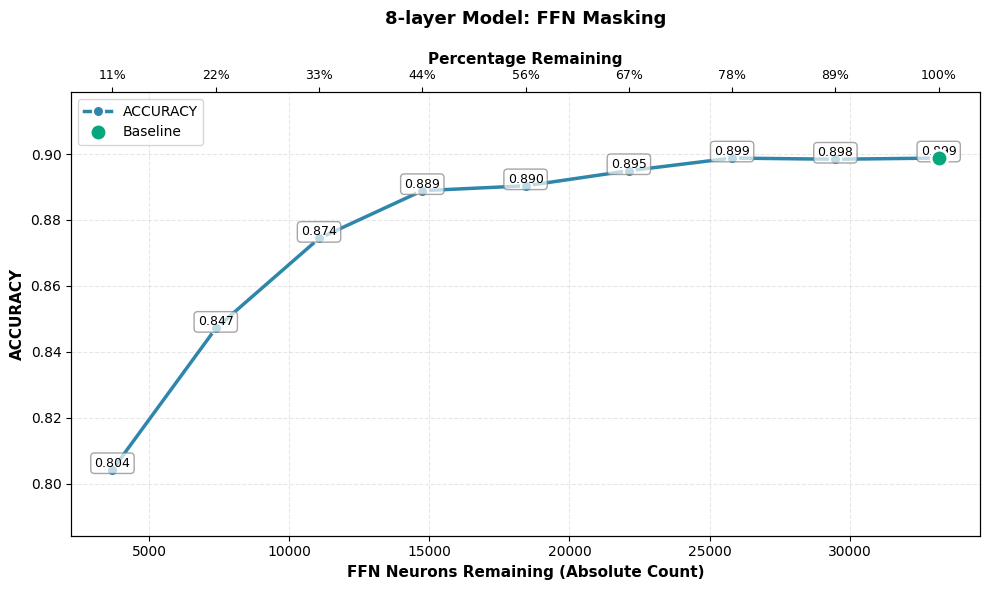

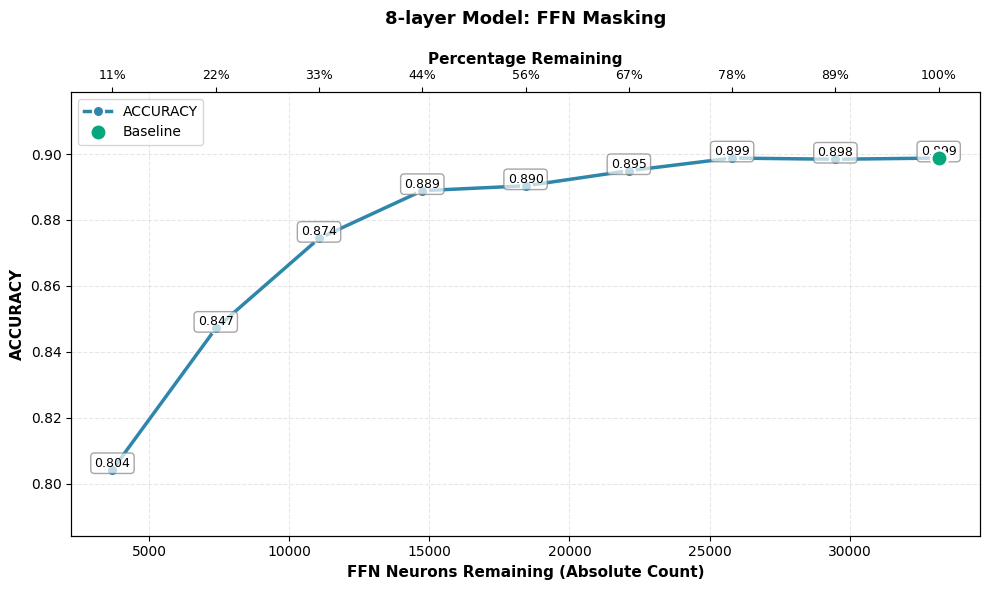

In [83]:
plot_results(mask_history_neuron_8, metric='accuracy', component='ffn', title='8-layer Model: FFN Masking')

In [84]:
remove_importance_masks(model_8, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [85]:
torch.save(mask_history_neuron_8, analysis_save_path + '/neuron_8.pt')

### 7 Layers

In [86]:
register_importance_masks(model_7, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (6144 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (9216 neurons)
  Layer 5: Registered masks (9216 neurons)
  Layer 6: Registered masks (3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [87]:
mask_history_neuron_7 = iterativeMask(
    model_7, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9019

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.90it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3068 (99.87%)
Layer: 1, total: 6144, Remain: 6137 (99.89%)
Layer: 2, total: 3072, Remain: 3072 (100.0%)
Layer: 3, total: 3072, Remain: 3071 (99.97%)
Layer: 4, total: 9216, Remain: 9192 (99.74%)
Layer: 5, total: 9216, Remain: 8208 (89.06%)
Layer: 6, total: 3072, Remain: 430 (14.0%)
  Metrics:
    ★ accuracy: 0.9024

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.93it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3036 (98.83%)
Layer: 1, total: 6144, Remain: 6089 (99.1%)
Layer: 2, total: 3072, Remain: 3063 (99.71%)
Layer: 3, total: 3072, Remain: 3069 (99.9%)
Layer: 4, total: 9216, Remain: 9050 (98.2%)
Layer: 5, total: 9216, Remain: 5038 (54.67%)
Layer: 6, total: 3072, Remain: 147 (4.79%)
  Metrics:
    ★ accuracy: 0.9021

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1440 (46.88%)
Layer: 1, total: 6144, Remain: 2307 (37.55%)
Layer: 2, total: 3072, Remain: 1700 (55.34%)
Layer: 3, total: 3072, Remain: 2051 (66.76%)
Layer: 4, total: 9216, Remain: 3125 (33.91%)
Layer: 5, total: 9216, Remain: 431 (4.68%)
Layer: 6, total: 3072, Remain: 8 (0.26%)
  Metrics:
    ★ accuracy: 0.8777

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.91it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1036 (33.72%)
Layer: 1, total: 6144, Remain: 1513 (24.63%)
Layer: 2, total: 3072, Remain: 1024 (33.33%)
Layer: 3, total: 3072, Remain: 1396 (45.44%)
Layer: 4, total: 9216, Remain: 2123 (23.04%)
Layer: 5, total: 9216, Remain: 277 (3.01%)
Layer: 6, total: 3072, Remain: 7 (0.23%)
  Metrics:
    ★ accuracy: 0.8552

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:23<00:00,  4.28it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 676 (22.01%)
Layer: 1, total: 6144, Remain: 849 (13.82%)
Layer: 2, total: 3072, Remain: 455 (14.81%)
Layer: 3, total: 3072, Remain: 602 (19.6%)
Layer: 4, total: 9216, Remain: 946 (10.26%)
Layer: 5, total: 9216, Remain: 156 (1.69%)
Layer: 6, total: 3072, Remain: 6 (0.2%)
  Metrics:
    ★ accuracy: 0.8170


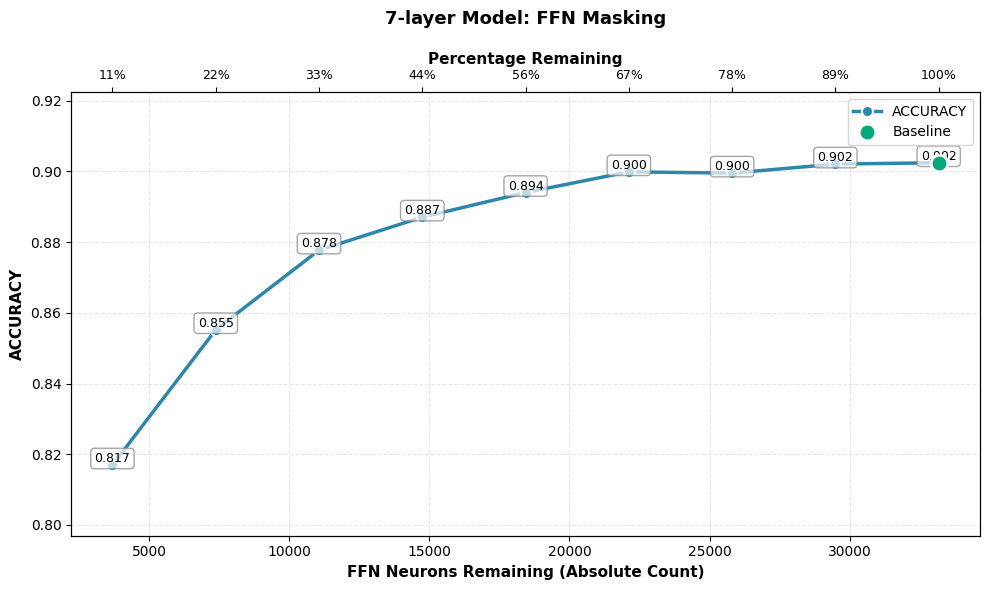

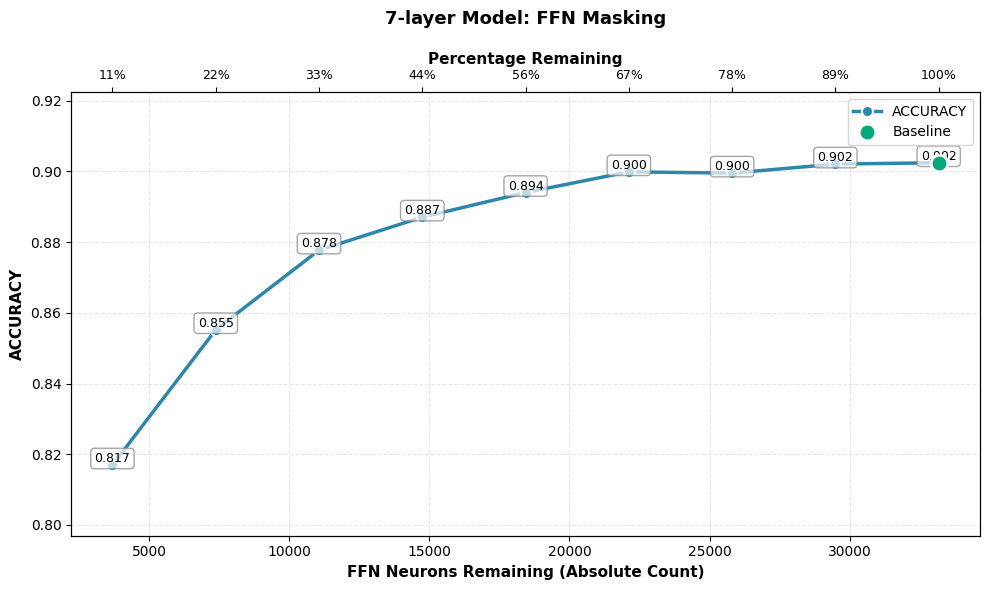

In [88]:
plot_results(mask_history_neuron_7, metric='accuracy', component='ffn', title='7-layer Model: FFN Masking')

In [89]:
remove_importance_masks(model_7, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [90]:
torch.save(mask_history_neuron_7, analysis_save_path + '/neuron_7.pt')

### 6 Layers

In [91]:
register_importance_masks(model_6, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (6144 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (18432 neurons)
  Layer 5: Registered masks (3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [92]:
mask_history_neuron_6 = iterativeMask(
    model_6, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.8832

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.95it/s]


Masking 3686 / 36864 neurons (10.0%)


Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3069 (99.9%)
Layer: 1, total: 6144, Remain: 6142 (99.97%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 3072, Remain: 3072 (100.0%)
Layer: 4, total: 18432, Remain: 16974 (92.09%)
Layer: 5, total: 3072, Remain: 850 (27.67%)
  Metrics:
    ★ accuracy: 0.8845

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.98it/s]


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1881 (61.23%)
Layer: 1, total: 6144, Remain: 3108 (50.59%)
Layer: 2, total: 3072, Remain: 2143 (69.76%)
Layer: 3, total: 3072, Remain: 2285 (74.38%)
Layer: 4, total: 18432, Remain: 1635 (8.87%)
Layer: 5, total: 3072, Remain: 10 (0.33%)
  Metrics:
    ★ accuracy: 0.8537

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:20<00:00,  4.77it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1327 (43.2%)
Layer: 1, total: 6144, Remain: 1944 (31.64%)
Layer: 2, total: 3072, Remain: 1371 (44.63%)
Layer: 3, total: 3072, Remain: 1675 (54.52%)
Layer: 4, total: 18432, Remain: 1049 (5.69%)
Layer: 5, total: 3072, Remain: 10 (0.33%)
  Metrics:
    ★ accuracy: 0.8411

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:21<00:00,  4.66it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 788 (25.65%)
Layer: 1, total: 6144, Remain: 1010 (16.44%)
Layer: 2, total: 3072, Remain: 549 (17.87%)
Layer: 3, total: 3072, Remain: 768 (25.0%)
Layer: 4, total: 18432, Remain: 567 (3.08%)
Layer: 5, total: 3072, Remain: 8 (0.26%)
  Metrics:
    ★ accuracy: 0.8104


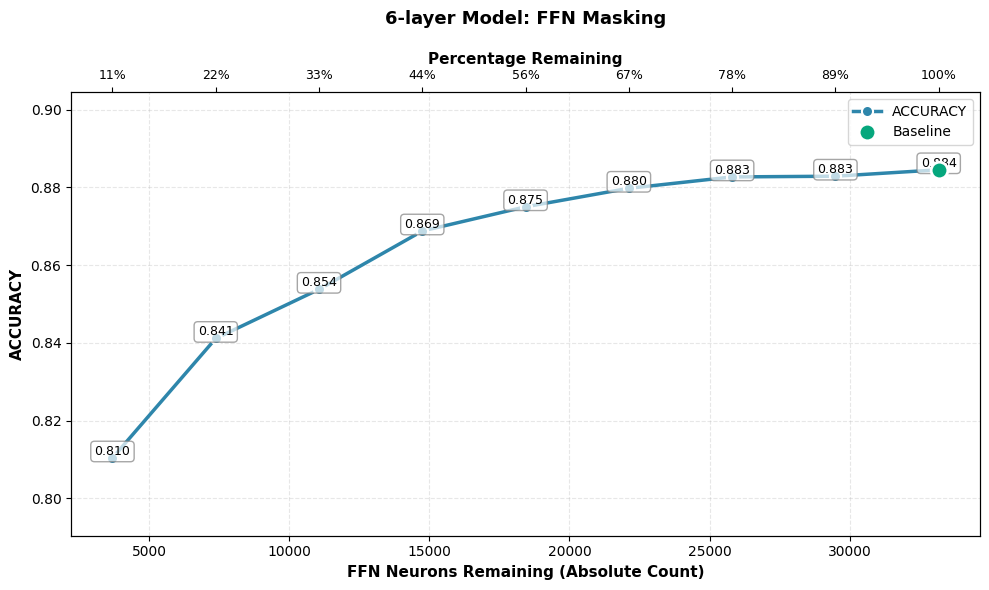

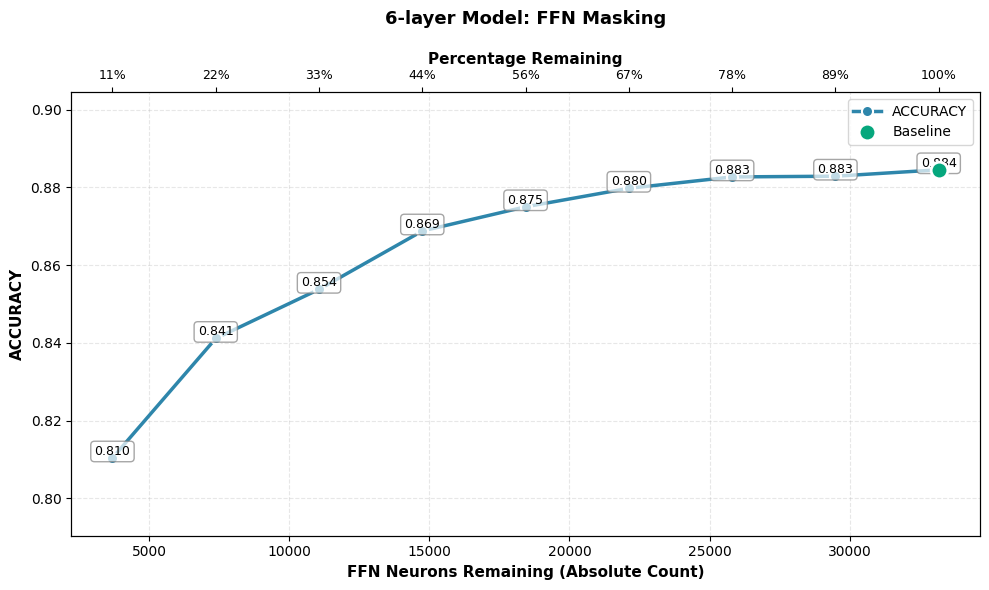

In [93]:
plot_results(mask_history_neuron_6, metric='accuracy', component='ffn', title='6-layer Model: FFN Masking')

In [94]:
remove_importance_masks(model_6, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [95]:
torch.save(mask_history_neuron_6, analysis_save_path + '/neuron_6.pt')

### Plot Comparision

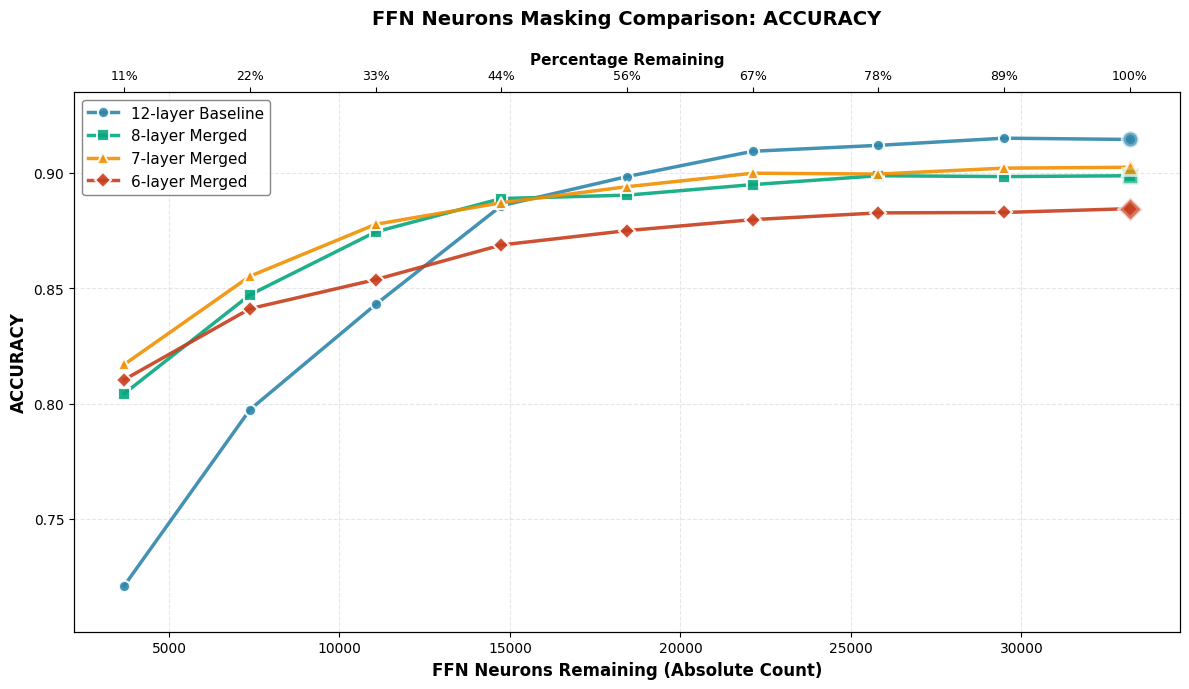

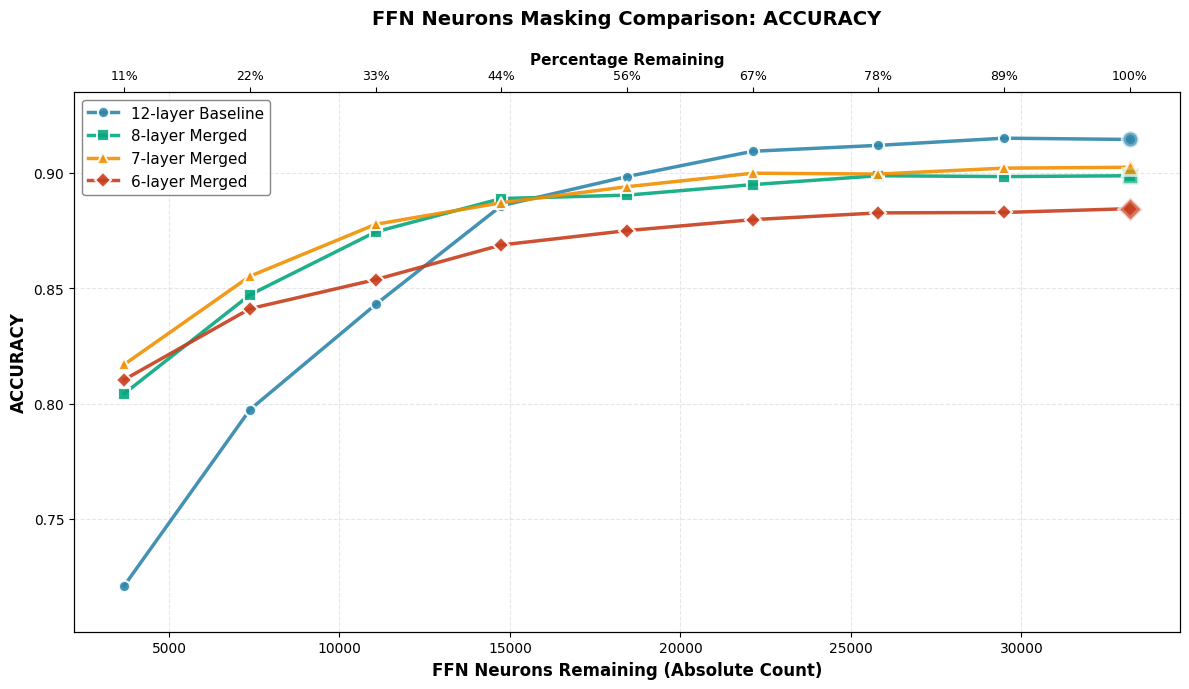

In [96]:
plot_masking_comparison(
    [mask_history_neuron, mask_history_neuron_8, mask_history_neuron_7, mask_history_neuron_6], 
    labels=['12-layer Baseline', '8-layer Merged', '7-layer Merged', '6-layer Merged'], 
    metric='accuracy', component='ffn'
)